# A GFlowNet action decoder for a toy VLA

This notebook is a minimal, end-to-end runnable version of the idea:

* keep a VLA's **vision-language backbone** (here: a tiny joint transformer over image patches,
  instruction tokens and action tokens),
* keep the **discretised action-chunk tokens** and the **same DAG of partial token assignments**
  that discrete-diffusion VLAs denoise over (states = chunks with some tokens masked, edges = reveal one token),
* and swap the **decoder training objective** from masked-token cross-entropy (discrete diffusion) to
  **trajectory balance with a simulator reward** (GFlowNet), optionally letting the policy **learn the
  generation order** as well.

The task is deliberately tiny so that four decoders can be compared on the same (pre-trained) backbone, the
same tokenisation and the same DAG; the whole notebook runs in ~12 min on a GPU or Apple-silicon machine
(~35 min on CPU with the `FAST` budget):

| Decoder | Training signal | Generation order |
|---|---|---|
| `DD / random`     | masked cross-entropy on (biased) demonstrations | random (standard discrete diffusion) |
| `DD / confidence` | same model as above                             | lowest-entropy token first (the adaptive heuristic of Discrete Diffusion VLA) |
| `GFN / fixed`     | trajectory balance on the simulator reward (demos only as exploration seeds) | random (same DAG, same sampler as `DD / random`) |
| `GFN / learned`   | trajectory balance on the simulator reward (demos only as exploration seeds) | learned jointly with the token values, with a learned backward policy |

**Toy task.** A point robot (green) sits at the bottom of a 32x32 image. Two coloured targets (red, blue)
are placed at the top and a grey obstacle sits between the robot and the instructed target.
The instruction (`"go to the red target"`, `"reach the blue goal"`, ...) says which target to reach.
The action chunk is `H = 8` steps of `(dx, dy)`, each dimension quantised into `K = 7` bins, i.e. `L = 16`
action tokens. Reaching the target requires going around the obstacle on the left **or** the right:
the task is genuinely multi-modal, which is where reward-proportional sampling should matter.

The demonstration set used for the discrete-diffusion baseline is deliberately **biased** (the scripted
demonstrator prefers the left detour 85% of the time): maximum likelihood will faithfully copy that bias,
whereas a decoder trained to sample proportionally to reward should cover both detours.

> Caveat up front: this is a testbed, not a result. Both decoders are small and trained for a few thousand
> steps, so absolute success rates are modest and differ from seed to seed; what the notebook is built to
> show is the *mechanism* (same DAG, different objective, different mode coverage) and the knobs you would
> turn in a real VLA (reward terms, replay, generation order, parallel decoding). Section 8 adds the baselines
> that make the comparison fair (matched data, reward at inference, RL fine-tuning on the same reward), and
> section 13 summarises what they show.

In [1]:
import math, os, time
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE, "| torch", torch.__version__)

# Iteration budgets. On a GPU / Apple-silicon MPS the whole notebook takes ~12 min; on CPU the two GFlowNet runs
# dominate (~15 min each), so FAST halves them (results are noisier but the qualitative picture is the same).
FAST = DEVICE.type == "cpu"
N_ITERS_BACKBONE, N_ITERS_DD, N_ITERS_GFN = 2000, 3000, (1500 if FAST else 3000)

# Fixed categorical colours for the four decoders (and a few scene colours).
COL = {
    "DD / random": "#2a78d6",
    "DD / confidence": "#eb6834",
    "DD / 200k demos": "#eda100",
    "DD / best-of-8": "#e87ba4",
    "DD + PG": "#e34948",
    "GFN / fixed": "#1baf7a",
    "GFN / learned": "#4a3aa7",
    "fail": "#9a9a94",
    "demo": "#0b0b0b",
}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6, "legend.frameon": False,
})

device: mps | torch 2.14.1


## 1. Configuration

In [2]:
@dataclass
class Cfg:
    # --- action chunk tokenisation ---
    H: int = 8            # chunk horizon (steps)
    D: int = 2            # action dims per step (dx, dy)
    K: int = 7            # bins per dimension  -> vocab = K value tokens + 1 [MASK]
    A_MAX: float = 0.15   # |displacement| per step per dim is in [-A_MAX, A_MAX]
    # --- environment ---
    IMG: int = 32
    OBS_HALF: float = 0.10
    ROBOT_R: float = 0.02
    GOAL_R: float = 0.08
    T_LANG: int = 5
    # --- compositional reward:  log R = -b_dist*dist - b_coll*coll - b_smooth*smooth + bonus*clean_success ---
    BETA_DIST: float = 40.0
    BETA_COLL: float = 30.0
    BETA_SMOOTH: float = 2.0
    BONUS_SUCCESS: float = 8.0
    # --- model ---
    d_model: int = 64
    n_layers: int = 3
    n_heads: int = 4

    @property
    def L(self):            # number of action tokens in a chunk
        return self.H * self.D

    @property
    def MASK(self):         # id of the [MASK] token
        return self.K


cfg = Cfg()
L, K, MASK = cfg.L, cfg.K, cfg.MASK
BIN_CENTERS = torch.linspace(-cfg.A_MAX, cfg.A_MAX, cfg.K)
BIN_CENTERS_NP = BIN_CENTERS.numpy()
print(f"chunk = {cfg.H} steps x {cfg.D} dims = {L} tokens, {K} bins each -> {K**L:.2e} possible chunks")

chunk = 8 steps x 2 dims = 16 tokens, 7 bins each -> 3.32e+13 possible chunks


## 2. Toy environment: scenes, rendering, instructions, dynamics, reward

A *scene* is (robot start, obstacle centre, two target positions, which target is instructed).
The VLA only sees the rendered image and the instruction tokens; the simulator (used for the reward and for
evaluation) sees the underlying geometry.

In [3]:
VOCAB = ["<pad>", "go", "to", "the", "red", "blue", "target", "move", "square", "reach", "goal"]
W2I = {w: i for i, w in enumerate(VOCAB)}
TEMPLATES = ["go to the {} target", "move to the {} square", "reach the {} goal"]
COLOURS = ["red", "blue"]


def encode_instruction(goal_idx, template_idx):
    words = TEMPLATES[template_idx].format(COLOURS[goal_idx]).split()
    return [W2I[w] for w in words] + [0] * (cfg.T_LANG - len(words))


def sample_scenes(n, rng):
    """Random scenes as a dict of numpy arrays."""
    start = np.stack([rng.uniform(0.25, 0.75, n), np.full(n, 0.10)], 1)
    tx = np.zeros((n, 2))
    tx[:, 0] = rng.uniform(0.10, 0.90, n)
    tx[:, 1] = rng.uniform(0.10, 0.90, n)
    bad = np.abs(tx[:, 0] - tx[:, 1]) < 0.30          # keep the two targets well separated
    while bad.any():
        tx[bad, 1] = rng.uniform(0.10, 0.90, bad.sum())
        bad = np.abs(tx[:, 0] - tx[:, 1]) < 0.30
    ty = rng.uniform(0.82, 0.95, (n, 2))
    targets = np.stack([tx, ty], -1)                   # (n, 2, 2): [red, blue]
    goal_idx = rng.integers(0, 2, n)
    goal = targets[np.arange(n), goal_idx]
    # obstacle roughly on the straight line between start and the instructed target
    ox = np.clip(0.5 * (start[:, 0] + goal[:, 0]) + rng.uniform(-0.06, 0.06, n), 0.2, 0.8)
    oy = rng.uniform(0.42, 0.55, n)
    obstacle = np.stack([ox, oy], 1)
    template = rng.integers(0, len(TEMPLATES), n)
    lang = np.array([encode_instruction(g, t) for g, t in zip(goal_idx, template)])
    return dict(start=start.astype(np.float32), targets=targets.astype(np.float32),
                goal_idx=goal_idx, goal=goal.astype(np.float32),
                obstacle=obstacle.astype(np.float32), lang=lang)


def render(sc):
    """Rasterise scenes into (n, 3, IMG, IMG) float images. Row 0 is the top of the workspace (y = 1)."""
    n, IMG = len(sc["start"]), cfg.IMG
    px = (np.arange(IMG) + 0.5) / IMG
    X, Y = np.meshgrid(px, px[::-1])
    img = np.zeros((n, 3, IMG, IMG), np.float32)

    def box(c, half):
        return (np.abs(X[None] - c[:, 0, None, None]) <= half) & (np.abs(Y[None] - c[:, 1, None, None]) <= half)

    def disk(c, r):
        return (X[None] - c[:, 0, None, None]) ** 2 + (Y[None] - c[:, 1, None, None]) ** 2 <= r ** 2

    for mask, colour in [
        (box(sc["obstacle"], cfg.OBS_HALF), (0.55, 0.55, 0.55)),
        (box(sc["targets"][:, 0], 0.045), (1.00, 0.20, 0.20)),
        (box(sc["targets"][:, 1], 0.045), (0.20, 0.40, 1.00)),
        (disk(sc["start"], 0.04), (0.20, 1.00, 0.20)),
    ]:
        for ch, v in enumerate(colour):
            img[:, ch][mask] = v
    return img


def to_torch(sc, device=DEVICE):
    out = {k: torch.as_tensor(v, device=device) for k, v in sc.items()}
    out["img"] = torch.as_tensor(render(sc), device=device)
    return out


def tokens_to_actions(tok):
    """(B, L) token ids -> (B, H, D) continuous displacements."""
    return BIN_CENTERS.to(tok.device)[tok].view(tok.shape[0], cfg.H, cfg.D)


def rollout(actions, start):
    """Point-robot dynamics: integrate displacements, clamp to the unit square. -> (B, H+1, 2)"""
    pos = [start]
    for t in range(cfg.H):
        pos.append((pos[-1] + actions[:, t]).clamp(0.0, 1.0))
    return torch.stack(pos, 1)


def collision_fraction(pos, obstacle, n_sub=8):
    """Fraction of (sub-sampled) path points inside the robot-inflated obstacle box."""
    a, b = pos[:, :-1], pos[:, 1:]
    lam = torch.linspace(0, 1, n_sub, device=pos.device).view(1, 1, n_sub, 1)
    pts = a.unsqueeze(2) + lam * (b - a).unsqueeze(2)                  # (B, H, n_sub, 2)
    inside = ((pts - obstacle[:, None, None]).abs() <= cfg.OBS_HALF + cfg.ROBOT_R).all(-1)
    return inside.float().mean((1, 2))


def path_side(pos, obstacle):
    """-1 if the path passes the obstacle on the left, +1 on the right (x at the point closest to the obstacle's y)."""
    idx = (pos[:, :, 1] - obstacle[:, None, 1]).abs().argmin(1)
    x_at = pos[torch.arange(pos.shape[0], device=pos.device), idx, 0]
    return torch.sign(x_at - obstacle[:, 0])


def simulate(tok, sc):
    """Run a batch of token chunks through the simulator and return per-sample statistics."""
    B = tok.shape[0]
    acts = tokens_to_actions(tok)
    pos = rollout(acts, sc["start"])
    d_goal = (pos[:, -1] - sc["goal"]).norm(dim=-1)
    other = sc["targets"][torch.arange(B, device=tok.device), 1 - sc["goal_idx"]]
    d_other = (pos[:, -1] - other).norm(dim=-1)
    coll = collision_fraction(pos, sc["obstacle"])
    smooth = (acts[:, 1:] - acts[:, :-1]).pow(2).sum((1, 2))
    success = d_goal < cfg.GOAL_R
    return dict(pos=pos, d_goal=d_goal, d_other=d_other, coll=coll, smooth=smooth,
                success=success, clean=success & (coll == 0), side=path_side(pos, sc["obstacle"]))


def log_reward(tok, sc):
    """Compositional reward: task success + distance shaping + collision constraint + smoothness. Strictly positive R."""
    e = simulate(tok, sc)
    return (-cfg.BETA_DIST * e["d_goal"] - cfg.BETA_COLL * e["coll"]
            - cfg.BETA_SMOOTH * e["smooth"] + cfg.BONUS_SUCCESS * e["clean"].float())


def decode_instruction(ids):
    return " ".join(VOCAB[i] for i in ids if i != 0)

## 3. Scripted (biased) demonstrator

The demonstrator plans a polyline `start -> below-obstacle corner -> above-obstacle corner -> target`,
picks the **left** detour with probability 0.85, re-samples `H` equally spaced waypoints and greedily
quantises each step into the action bins with error feedback. Only demonstrations that reach the target
without touching the obstacle are kept.

In [4]:
def plan_demo(start, obstacle, goal, rng, p_left=0.85, margin=0.08):
    side = -1.0 if rng.random() < p_left else 1.0
    off = cfg.OBS_HALF + cfg.ROBOT_R + margin
    via1 = np.array([obstacle[0] + side * off, obstacle[1] - off])
    via2 = np.array([obstacle[0] + side * off, obstacle[1] + off])
    pts = np.stack([start, via1, via2, goal])
    seg_len = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    cum = np.concatenate([[0.0], np.cumsum(seg_len)])
    s = np.linspace(0.0, cum[-1], cfg.H + 1)[1:]
    wps = np.stack([np.interp(s, cum, pts[:, i]) for i in range(2)], 1)   # (H, 2)
    pos, toks = start.copy(), []
    for t in range(cfg.H):
        desired = wps[t] - pos
        k = np.abs(desired[:, None] - BIN_CENTERS_NP[None]).argmin(1)
        toks.extend(k.tolist())
        pos = np.clip(pos + BIN_CENTERS_NP[k], 0.0, 1.0)
    return np.array(toks), side


def make_demos(n, rng, p_left=0.85):
    """Clean, successful demonstrations as a dict of numpy arrays (scene geometry, instruction, 'tok').
    Images are rendered per batch at training time, so large demo sets stay small in memory."""
    sc = sample_scenes(n, rng)
    toks, sides = zip(*[plan_demo(sc["start"][i], sc["obstacle"][i], sc["goal"][i], rng, p_left) for i in range(n)])
    toks, sides = np.stack(toks), np.array(sides)
    geo = {k: torch.as_tensor(v, device=DEVICE) for k, v in sc.items()}          # simulate() needs no image
    keep = simulate(torch.as_tensor(toks, device=DEVICE), geo)["clean"].cpu().numpy()
    demos = {k: v[keep] for k, v in sc.items()}
    demos["tok"] = toks[keep]
    print(f"demos: kept {keep.sum()}/{n} clean successes "
          f"({keep.mean():.1%}); left-detour fraction = {(sides[keep] < 0).mean():.2f}")
    return demos


def demo_batch(demos, idx):
    """Render and move a subset of a demo set to the device."""
    return to_torch({k: v[idx] for k, v in demos.items()})


rng = np.random.default_rng(SEED)
DEMOS = make_demos(6000, rng)
N_DEMOS = DEMOS["tok"].shape[0]
DEMOS_T = demo_batch(DEMOS, np.arange(N_DEMOS))       # the 6k set rendered once: used for plotting and GFN replay

demos: kept 6000/6000 clean successes (100.0%); left-detour fraction = 0.85


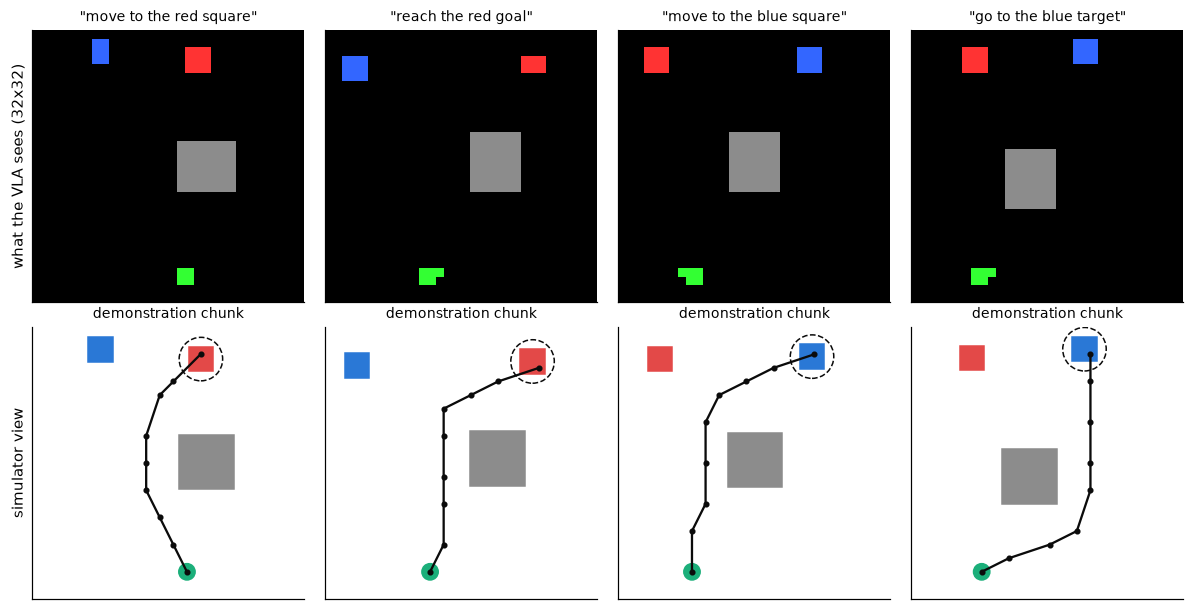

In [5]:
def draw_scene(ax, sc, i, title=None):
    """Draw scene i of a (numpy or torch) scene dict in workspace coordinates."""
    g = lambda k: np.asarray(sc[k][i].cpu() if torch.is_tensor(sc[k]) else sc[k][i])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal"); ax.grid(False)
    ax.set_xticks([]); ax.set_yticks([])
    o = g("obstacle")
    ax.add_patch(plt.Rectangle(o - cfg.OBS_HALF, 2 * cfg.OBS_HALF, 2 * cfg.OBS_HALF, color="#8c8c8c"))
    for t, c in zip(g("targets"), ["#e34948", "#2a78d6"]):
        ax.add_patch(plt.Rectangle(t - 0.045, 0.09, 0.09, color=c))
    gi = int(g("goal_idx"))
    ax.add_patch(plt.Circle(g("targets")[gi], cfg.GOAL_R, fill=False, ls="--", lw=1, color="#0b0b0b"))
    ax.add_patch(plt.Circle(g("start"), 0.03, color="#1baf7a"))
    if title is not None:
        ax.set_title(title, fontsize=9)


fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
for j in range(4):
    img = DEMOS_T["img"][j].cpu().numpy().transpose(1, 2, 0)
    axes[0, j].imshow(img); axes[0, j].set_xticks([]); axes[0, j].set_yticks([]); axes[0, j].grid(False)
    axes[0, j].set_title(f'"{decode_instruction(DEMOS_T["lang"][j].tolist())}"', fontsize=9)
    draw_scene(axes[1, j], DEMOS_T, j, title="demonstration chunk")
    p = simulate(DEMOS_T["tok"][j:j + 1], {k: v[j:j + 1] for k, v in DEMOS_T.items()})["pos"][0].cpu().numpy()
    axes[1, j].plot(p[:, 0], p[:, 1], "-o", ms=3, lw=1.5, color=COL["demo"])
axes[0, 0].set_ylabel("what the VLA sees (32x32)")
axes[1, 0].set_ylabel("simulator view")
plt.tight_layout(); plt.show()

## 4. The DAG of partial token assignments

A state is a chunk of `L` tokens, each either revealed (one of `K` bins) or `[MASK]`. The initial state
`s_0` is all-masked; terminal states are fully revealed chunks `x`. An edge `s -> s'` reveals exactly one
token, so every trajectory has length `L` and every `x` is reachable by `L!` orderings.

* **Forward policy**  `P_F(s'|s, c) = P(position i | s, c) * P(value v | i, s, c)`, conditioned on the VLM
  context `c`. With a *fixed random order*, `P(i | s) = 1 / #masked(s)`; with a *learned order* it is a
  softmax over the masked positions produced by the same network.
* **Backward policy** `P_B(s|s')`: which revealed token of `s'` was revealed last. For the fixed-order model it is
  uniform, `1 / #revealed(s')`, so along any full trajectory `sum_t log P_B = -log L!` is a constant. For the
  learned-order model it is a second head of the same network. This is not optional: with a *uniform* `P_B`,
  trajectory balance forces `P_F(tau) = R(x) / (Z L!)` for **every** reveal order `tau` of `x`, i.e. the forward
  order is pinned to uniform at the fixed point and nothing can be learned about it. A learned `P_B` lets the
  forward policy concentrate on the orders it finds easiest while still satisfying `P_F(x) = R(x)/Z`.
* **Trajectory balance**: `log Z(c) + sum_t log P_F = log R(x|c) + sum_t log P_B`.

Discrete diffusion is the maximum-likelihood special case: train `P(value | i, s, c)` with masked
cross-entropy on demonstrations, decode with a fixed or heuristic order. The GFlowNet keeps the DAG and the
network, but replaces the objective by TB against the simulator reward (no demonstrations needed) and can make
`P(i | s, c)` a trainable component.

## 5. Toy VLA: one transformer over [image patches | instruction tokens | action tokens]

Outputs, read at the action positions: value logits `(L, K)` (used by all decoders), a *select* logit per
position for the forward order and an *unreveal* logit per position for the backward policy (learned-order
GFN only), and `log Z(c)` read from the context tokens in the all-masked state.

In [6]:
N_PATCH = (cfg.IMG // 8) ** 2            # 4x4 = 16 image tokens
N_CTX = N_PATCH + cfg.T_LANG


class ToyVLA(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d = cfg.d_model
        self.patch = nn.Sequential(nn.Conv2d(3, d // 2, 4, stride=4), nn.GELU(),
                                   nn.Conv2d(d // 2, d, 2, stride=2), nn.GELU())    # 32 -> 8 -> 4
        self.lang = nn.Embedding(len(VOCAB), d)
        self.act = nn.Embedding(cfg.K + 1, d)                                     # + [MASK]
        self.tok_type = nn.Embedding(3, d)                                            # image / language / action
        self.pos = nn.Parameter(torch.randn(1, N_CTX + cfg.L, d) * 0.02)
        layer = nn.TransformerEncoderLayer(d, cfg.n_heads, 4 * d, dropout=0.0, activation="gelu",
                                           batch_first=True, norm_first=True)
        self.tf = nn.TransformerEncoder(layer, cfg.n_layers, enable_nested_tensor=False)
        self.norm = nn.LayerNorm(d)
        self.value_head = nn.Linear(d, cfg.K)
        self.select_head = nn.Linear(d, 1)        # P_F over which masked token to reveal next   (learned order)
        self.unreveal_head = nn.Linear(d, 1)      # P_B over which revealed token was revealed last (learned order)
        self.logZ_head = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.Linear(d, 1))
        self.ground_head = nn.Linear(d, 4)        # backbone pre-training only: (goal - start, obstacle - start)

    def embed_context(self, img, lang):
        v = self.patch(img).flatten(2).transpose(1, 2) + self.tok_type.weight[0]
        l = self.lang(lang) + self.tok_type.weight[1]
        return torch.cat([v, l], 1)                                               # (B, N_CTX, d)

    def forward(self, ctx, act_tokens):
        a = self.act(act_tokens) + self.tok_type.weight[2]
        h = self.norm(self.tf(torch.cat([ctx, a], 1) + self.pos))
        ha = h[:, N_CTX:]
        return (self.value_head(ha),                       # (B, L, K)
                self.select_head(ha).squeeze(-1),          # (B, L)
                self.unreveal_head(ha).squeeze(-1),        # (B, L)
                self.logZ_head(h[:, :N_CTX].mean(1)).squeeze(-1))   # (B,)

    def ground(self, ctx):
        """Grounding read-out used for backbone pre-training: run the all-masked state s_0 and regress scene geometry."""
        a = self.act(torch.full(ctx.shape[:1] + (cfg.L,), cfg.MASK, dtype=torch.long, device=ctx.device)) + self.tok_type.weight[2]
        h = self.norm(self.tf(torch.cat([ctx, a], 1) + self.pos))
        return self.ground_head(h[:, :N_CTX].mean(1))


def n_params(m):
    return sum(p.numel() for p in m.parameters())


print(f"ToyVLA: {n_params(ToyVLA(cfg)) / 1e3:.0f}k parameters")

ToyVLA: 169k parameters


### 5b. Backbone pre-training (stand-in for VLM pre-training)

A real VLA inherits visual grounding of language from its VLM. The toy backbone has no such prior, so we give it
one with a cheap reward-free grounding task on random scenes: from image + instruction, regress the instructed
target's and the obstacle's position relative to the robot. **Every decoder below starts from this same
checkpoint**, so the comparison isolates the action-decoding objective.

In [7]:
def pretrain_backbone(model, n_iters=2000, batch=128, lr=1e-3, log_every=500, seed=7):
    rng = np.random.default_rng(seed)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, n_iters)
    t0 = time.time()
    for it in range(1, n_iters + 1):
        sc = to_torch(sample_scenes(batch, rng))
        target = torch.cat([sc["goal"] - sc["start"], sc["obstacle"] - sc["start"]], 1)
        loss = (model.ground(model.embed_context(sc["img"], sc["lang"])) - target).pow(2).mean()
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        if it % log_every == 0:
            print(f"[backbone] it {it:5d}  grounding RMSE {loss.sqrt().item():.3f}  ({time.time() - t0:.0f}s)")
    return model


BACKBONE = pretrain_backbone(ToyVLA(cfg).to(DEVICE), n_iters=N_ITERS_BACKBONE)
with torch.no_grad():
    sc = to_torch(sample_scenes(512, np.random.default_rng(99)))
    pred = BACKBONE.ground(BACKBONE.embed_context(sc["img"], sc["lang"]))
    other = sc["targets"][torch.arange(512, device=DEVICE), 1 - sc["goal_idx"]] - sc["start"]
    wrong = ((pred[:, :2] - other).norm(dim=1) < (pred[:, :2] - (sc["goal"] - sc["start"])).norm(dim=1)).float().mean()
    print(f"held-out: predicted goal closer to the distractor in {wrong:.1%} of scenes")


def fresh_model():
    """A new decoder initialised from the pre-trained backbone."""
    m = ToyVLA(cfg).to(DEVICE)
    m.load_state_dict(BACKBONE.state_dict())
    return m

[backbone] it   500  grounding RMSE 0.163  (6s)


[backbone] it  1000  grounding RMSE 0.051  (11s)


[backbone] it  1500  grounding RMSE 0.042  (17s)


[backbone] it  2000  grounding RMSE 0.042  (22s)
held-out: predicted goal closer to the distractor in 1.6% of scenes


## 6. Baseline: discrete-diffusion training and decoding

Training: mask each token of a demonstration with probability `t ~ U(0,1)`, predict the masked tokens with
cross-entropy. Decoding: iteratively reveal masked tokens, one per step (so the sampler walks exactly the DAG
above), in a random order or in a lowest-entropy-first ("easy dimensions first") order. `n_steps < L`
reveals several tokens per step in parallel, as in MaskGIT-style decoding.

In [8]:
def dd_loss(model, ctx, x0):
    B = x0.shape[0]
    t = torch.rand(B, 1, device=x0.device)
    mask = torch.rand(B, L, device=x0.device) < t
    none = ~mask.any(1)
    if none.any():
        mask[none, torch.randint(0, L, (int(none.sum()),), device=x0.device)] = True
    vl, _, _, _ = model(ctx, x0.masked_fill(mask, MASK))
    ce = F.cross_entropy(vl.reshape(-1, K), x0.reshape(-1), reduction="none").view(B, L)
    return (ce * mask).sum() / mask.sum()


@torch.no_grad()
def dd_sample(model, ctx, order="random", n_steps=None):
    n_steps = n_steps or L
    B, dev = ctx.shape[0], ctx.device
    x = torch.full((B, L), MASK, dtype=torch.long, device=dev)
    reveal_step = torch.zeros(B, L, dtype=torch.long, device=dev)
    counts = [L // n_steps + (1 if i < L % n_steps else 0) for i in range(n_steps)]
    for step, n_rev in enumerate(counts):
        vl, _, _, _ = model(ctx, x)
        probs = F.softmax(vl, -1)
        cand = torch.multinomial(probs.view(-1, K), 1).view(B, L)
        masked = x == MASK
        if order == "random":
            score = torch.rand(B, L, device=dev)
        elif order == "confidence":                      # lowest entropy first
            score = (probs * torch.log(probs + 1e-9)).sum(-1)
        elif order == "l2r":                             # autoregressive-like
            score = -torch.arange(L, device=dev, dtype=torch.float).expand(B, L)
        else:
            raise ValueError(order)
        idx = score.masked_fill(~masked, -float("inf")).topk(n_rev, dim=1).indices
        x.scatter_(1, idx, cand.gather(1, idx))
        reveal_step.scatter_(1, idx, step)
    return x, reveal_step


def train_dd(model, demos=DEMOS, n_iters=3000, batch=128, lr=3e-4, log_every=250, seed=2):
    rng = np.random.default_rng(seed)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, n_iters)
    hist, t0 = [], time.time()
    for it in range(1, n_iters + 1):
        sc = demo_batch(demos, rng.integers(0, demos["tok"].shape[0], batch))
        ctx = model.embed_context(sc["img"], sc["lang"])
        loss = dd_loss(model, ctx, sc["tok"])
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        hist.append(loss.item())
        if it % log_every == 0:
            print(f"[DD] it {it:5d}  masked-CE {np.mean(hist[-log_every:]):.3f}  ({time.time() - t0:.0f}s)")
    return hist


dd_model = fresh_model()
dd_hist = train_dd(dd_model, n_iters=N_ITERS_DD)

[DD] it   250  masked-CE 1.344  (3s)


[DD] it   500  masked-CE 0.956  (7s)


[DD] it   750  masked-CE 0.896  (10s)


[DD] it  1000  masked-CE 0.866  (14s)


[DD] it  1250  masked-CE 0.847  (17s)


...

[DD] it  2000  masked-CE 0.811  (27s)


[DD] it  2250  masked-CE 0.797  (30s)


[DD] it  2500  masked-CE 0.797  (34s)


[DD] it  2750  masked-CE 0.788  (37s)


[DD] it  3000  masked-CE 0.792  (40s)


## 7. GFlowNet training over the same DAG

`gfn_sample` walks the DAG with the current forward policy (with `eps`-uniform exploration during training).
`tb_loss` recomputes `log P_F` for every visited state in one batched pass and applies trajectory balance.
With `learned_order=False` the sampler is identical to `dd_sample(order="random")`: only the loss differs.

Pure on-policy TB is sample-hungry on a `7^16` space, so `train_gfn` also replays stored chunks: half from a
prioritised buffer of the policy's own samples, half from the demonstration set. Because TB is an off-policy
objective, replayed trajectories can be re-drawn with the backward policy (a random reveal order), and the
demonstrations act purely as *exploration seeds*: the fixed point is still `P_F(x) = R(x)/Z`, not the
demonstration distribution, however often a chunk is replayed. (A single FIFO buffer that evicts the demos
lets prioritised replay amplify whichever mode the policy finds first, which is exactly the collapse we want to
avoid, so the demo buffer is kept separate and permanent.)

In [9]:
@torch.no_grad()
def gfn_sample(model, ctx, learned_order=True, eps=0.0):
    B, dev = ctx.shape[0], ctx.device
    x = torch.full((B, L), MASK, dtype=torch.long, device=dev)
    ar = torch.arange(B, device=dev)
    states, positions, values = [], [], []
    reveal_step = torch.zeros(B, L, dtype=torch.long, device=dev)
    for step in range(L):
        vl, sl, _, _ = model(ctx, x)
        masked = x == MASK
        if learned_order:
            p_pos = F.softmax(sl.masked_fill(~masked, -1e9), -1)
            if eps > 0:
                p_pos = (1 - eps) * p_pos + eps * masked.float() / masked.sum(1, keepdim=True)
        else:
            p_pos = masked.float()
        pos = torch.multinomial(p_pos, 1).squeeze(1)
        p_val = F.softmax(vl[ar, pos], -1)
        if eps > 0:
            p_val = (1 - eps) * p_val + eps / K
        val = torch.multinomial(p_val, 1).squeeze(1)
        states.append(x.clone()); positions.append(pos); values.append(val)
        x[ar, pos] = val
        reveal_step[ar, pos] = step
    return x, torch.stack(states, 1), torch.stack(positions, 1), torch.stack(values, 1), reveal_step


LOG_PB_TRAJ = -math.lgamma(L + 1)       # sum_t log P_B = -log(L!) for the uniform backward policy


def policy_terms(model, ctx, states, positions, values, learned_order):
    """Per-step log-probabilities along a trajectory, recomputed in one batched pass. `states` are s_0..s_{L-1};
    the terminal chunk s_L is rebuilt from the last transition. Fixed order: P(pos) and P_B uniform (both
    constants). Learned order: P(pos) from the select head and P_B from the unreveal head (on the *next* state).
    Returns log Z(c), log P(pos_t), log P(val_t | pos_t), log P_B(s_t | s_{t+1}), each (B,) or (B, L)."""
    B = states.shape[0]
    ar = torch.arange(B, device=states.device)
    x = states[:, -1].clone()
    x[ar, positions[:, -1]] = values[:, -1]
    states_all = torch.cat([states, x.unsqueeze(1)], 1)                                   # (B, L+1, L)
    ctx_rep = ctx.unsqueeze(1).expand(-1, L + 1, -1, -1).reshape(B * (L + 1), *ctx.shape[1:])
    vl, sl, ul, logZ = model(ctx_rep, states_all.reshape(B * (L + 1), L))
    vl, sl, ul = vl.view(B, L + 1, L, K)[:, :-1], sl.view(B, L + 1, L)[:, :-1], ul.view(B, L + 1, L)[:, 1:]
    logZ = logZ.view(B, L + 1)[:, 0]                                       # log Z(c) read in the all-masked state
    masked = states == MASK                                                # (B, L, L) at s_0..s_{L-1}
    revealed_next = states_all[:, 1:] != MASK                              # (B, L, L) at s_1..s_L
    if learned_order:
        logp_pos = F.log_softmax(sl.masked_fill(~masked, -1e9), -1).gather(-1, positions.unsqueeze(-1)).squeeze(-1)
        logp_back = F.log_softmax(ul.masked_fill(~revealed_next, -1e9), -1).gather(-1, positions.unsqueeze(-1)).squeeze(-1)
    else:
        logp_pos = -torch.log(masked.sum(-1).float())                      # uniform over masked positions
        logp_back = -torch.log(revealed_next.sum(-1).float())              # uniform over revealed positions
    vl_sel = vl.gather(2, positions.view(B, L, 1, 1).expand(-1, -1, 1, K)).squeeze(2)
    logp_val = F.log_softmax(vl_sel, -1).gather(-1, values.unsqueeze(-1)).squeeze(-1)
    return logZ, logp_pos, logp_val, logp_back


def tb_loss(model, ctx, states, positions, values, logR, learned_order, order_coef=0.0):
    """Trajectory balance: (log Z + sum log P_F - log R - sum log P_B)^2."""
    logZ, logp_pos, logp_val, logp_back = policy_terms(model, ctx, states, positions, values, learned_order)
    resid = logZ + (logp_pos + logp_val).sum(1) - logR - logp_back.sum(1)
    loss = resid.pow(2).mean()
    if learned_order and order_coef > 0:
        # Optional auxiliary signal for the order policy: TB itself has no preference between reveal orders (see
        # section 11), so reinforce orders along which the current model is most self-consistent (small residual).
        r2 = resid.pow(2).detach()
        loss = loss + order_coef * (((r2 - r2.mean()) / (r2.std() + 1e-6)) * logp_pos.sum(1)).mean()
    return loss


@torch.no_grad()
def backward_trajectory(model, ctx, x, learned_order):
    """Sample a trajectory s_0 -> ... -> s_L = x from the backward policy P_B (uniform random reveal order for the
    fixed-order model, the unreveal head for the learned-order model). TB is valid for any trajectory with positive
    probability, so stored chunks can be replayed this way."""
    B, dev = x.shape[0], x.device
    ar = torch.arange(B, device=dev)
    cur, states, positions, values = x.clone(), [], [], []
    for _ in range(L):
        revealed = cur != MASK
        if learned_order:
            _, _, ul, _ = model(ctx, cur)
            p = F.softmax(ul.masked_fill(~revealed, -1e9), -1)
        else:
            p = revealed.float()
        pos = torch.multinomial(p, 1).squeeze(1)
        positions.append(pos); values.append(cur[ar, pos])
        cur[ar, pos] = MASK
        states.append(cur.clone())
    # reverse: states[-1] is s_0 (all masked); positions[-1] is the first reveal
    return (torch.stack(states[::-1], 1), torch.stack(positions[::-1], 1), torch.stack(values[::-1], 1))


class Replay:
    """Prioritised replay of (scene, chunk, log R). Sampling weight is softmax(log R / tau), so high-reward chunks
    (including demonstrations, if seeded) are revisited often. Off-policy training is sound for TB."""
    KEYS = ["start", "targets", "goal_idx", "goal", "obstacle", "lang", "img"]

    def __init__(self, cap=20000):
        self.cap, self.sc, self.tok, self.logR = cap, None, None, None

    def add(self, sc, tok, logR):
        new = {k: sc[k] for k in self.KEYS}
        if self.sc is None:
            self.sc, self.tok, self.logR = new, tok, logR
        else:
            self.sc = {k: torch.cat([self.sc[k], new[k]])[-self.cap:] for k in self.KEYS}
            self.tok, self.logR = torch.cat([self.tok, tok])[-self.cap:], torch.cat([self.logR, logR])[-self.cap:]

    def sample(self, n, tau=4.0):
        """tau=None samples uniformly."""
        p = F.softmax(self.logR / tau, 0) if tau is not None else torch.full_like(self.logR, 1.0 / len(self.logR))
        idx = torch.multinomial(p, n, replacement=True)
        return {k: v[idx] for k, v in self.sc.items()}, self.tok[idx], self.logR[idx]


def train_gfn(model, learned_order, n_iters=3000, batch=64, lr=2e-3, lr_logZ=1e-2, eps0=0.25,
              use_demos=True, demo_frac=0.5, replay_tau=4.0, order_coef=0.0, log_every=250, seed=1):
    """On-policy TB on fresh scenes + off-policy TB on replayed chunks: half from a prioritised buffer of the
    policy's own samples, half (with `use_demos=True`) drawn uniformly from the demonstration set. The reward,
    not the demonstrations, defines the target distribution: TB drives P_F(x) to R(x)/Z whatever the replay
    frequency of x, so the 85/15 demo bias is not inherited. `use_demos=False` works too, but prioritised replay
    of the policy's own samples alone can lock onto the first mode it finds (seed-dependent)."""
    rng = np.random.default_rng(seed)
    z_params = list(model.logZ_head.parameters())
    z_ids = {id(p) for p in z_params}
    opt = torch.optim.AdamW([{"params": [p for p in model.parameters() if id(p) not in z_ids], "lr": lr},
                             {"params": z_params, "lr": lr_logZ}], weight_decay=0.0)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, n_iters)
    buf, demo_buf = Replay(), None
    if use_demos:
        demo_buf = Replay()
        demo_buf.add(DEMOS_T, DEMOS_T["tok"], log_reward(DEMOS_T["tok"], DEMOS_T))
    hist, t0 = {"loss": [], "logR": [], "success": [], "clean": []}, time.time()
    for it in range(1, n_iters + 1):
        # (1) on-policy trajectories on fresh scenes, with eps-uniform exploration that decays to zero
        sc = to_torch(sample_scenes(batch, rng))
        ctx = model.embed_context(sc["img"], sc["lang"])
        eps = eps0 * max(0.0, 1.0 - it / (0.6 * n_iters))
        x, states, positions, values, _ = gfn_sample(model, ctx.detach(), learned_order, eps)
        logR = log_reward(x, sc)
        loss = tb_loss(model, ctx, states, positions, values, logR, learned_order, order_coef)
        # (2) off-policy trajectories replayed from stored chunks (random reveal order = P_B)
        buf.add(sc, x, logR)
        n_demo = int(batch * demo_frac) if demo_buf is not None else 0
        r_sc, r_x, r_logR = buf.sample(batch - n_demo, replay_tau)
        if n_demo:
            d_sc, d_x, d_logR = demo_buf.sample(n_demo, tau=None)
            r_sc = {k: torch.cat([r_sc[k], d_sc[k]]) for k in r_sc}
            r_x, r_logR = torch.cat([r_x, d_x]), torch.cat([r_logR, d_logR])
        r_ctx = model.embed_context(r_sc["img"], r_sc["lang"])
        loss = 0.5 * (loss + tb_loss(model, r_ctx, *backward_trajectory(model, r_ctx.detach(), r_x, learned_order), r_logR, learned_order))
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        e = simulate(x, sc)
        hist["loss"].append(loss.item()); hist["logR"].append(logR.mean().item())
        hist["success"].append(e["success"].float().mean().item()); hist["clean"].append(e["clean"].float().mean().item())
        if it % log_every == 0:
            m = lambda k: np.mean(hist[k][-log_every:])
            print(f"[GFN {'learned' if learned_order else 'fixed'}] it {it:5d}  TB {m('loss'):8.2f}  "
                  f"logR {m('logR'):6.2f}  on-policy success {m('success'):.2f}  clean {m('clean'):.2f}  "
                  f"eps {eps:.2f}  ({time.time() - t0:.0f}s)")
    return hist


gfn_fixed = fresh_model()
gfn_fixed_hist = train_gfn(gfn_fixed, learned_order=False, n_iters=N_ITERS_GFN)

[GFN fixed] it   250  TB   114.69  logR -17.73  on-policy success 0.05  clean 0.02  eps 0.22  (20s)


[GFN fixed] it   500  TB    58.39  logR -13.05  on-policy success 0.09  clean 0.04  eps 0.18  (40s)


[GFN fixed] it   750  TB    46.88  logR -10.74  on-policy success 0.12  clean 0.07  eps 0.15  (60s)


[GFN fixed] it  1000  TB    39.56  logR  -8.61  on-policy success 0.17  clean 0.11  eps 0.11  (80s)


[GFN fixed] it  1250  TB    36.66  logR  -7.06  on-policy success 0.21  clean 0.15  eps 0.08  (100s)


...

[GFN fixed] it  2000  TB    30.74  logR  -2.95  on-policy success 0.38  clean 0.30  eps 0.00  (161s)


[GFN fixed] it  2250  TB    28.39  logR  -2.47  on-policy success 0.40  clean 0.32  eps 0.00  (181s)


[GFN fixed] it  2500  TB    27.07  logR  -2.06  on-policy success 0.43  clean 0.35  eps 0.00  (201s)


[GFN fixed] it  2750  TB    25.75  logR  -1.65  on-policy success 0.46  clean 0.37  eps 0.00  (222s)


[GFN fixed] it  3000  TB    25.20  logR  -1.55  on-policy success 0.46  clean 0.38  eps 0.00  (242s)


In [10]:
gfn_learned = fresh_model()
gfn_learned_hist = train_gfn(gfn_learned, learned_order=True, n_iters=N_ITERS_GFN)

[GFN learned] it   250  TB   123.58  logR -18.70  on-policy success 0.05  clean 0.01  eps 0.22  (25s)


[GFN learned] it   500  TB    61.41  logR -13.63  on-policy success 0.09  clean 0.03  eps 0.18  (49s)


[GFN learned] it   750  TB    48.92  logR -10.71  on-policy success 0.13  clean 0.07  eps 0.15  (73s)


[GFN learned] it  1000  TB    39.53  logR  -8.57  on-policy success 0.18  clean 0.11  eps 0.11  (96s)


[GFN learned] it  1250  TB    34.98  logR  -6.54  on-policy success 0.24  clean 0.17  eps 0.08  (120s)


...

[GFN learned] it  2000  TB    27.43  logR  -1.58  on-policy success 0.48  clean 0.38  eps 0.00  (188s)


[GFN learned] it  2250  TB    24.30  logR  -0.88  on-policy success 0.52  clean 0.43  eps 0.00  (212s)


[GFN learned] it  2500  TB    22.04  logR  -0.34  on-policy success 0.57  clean 0.46  eps 0.00  (235s)


[GFN learned] it  2750  TB    20.56  logR   0.22  on-policy success 0.61  clean 0.50  eps 0.00  (258s)


[GFN learned] it  3000  TB    20.02  logR   0.22  on-policy success 0.60  clean 0.50  eps 0.00  (281s)


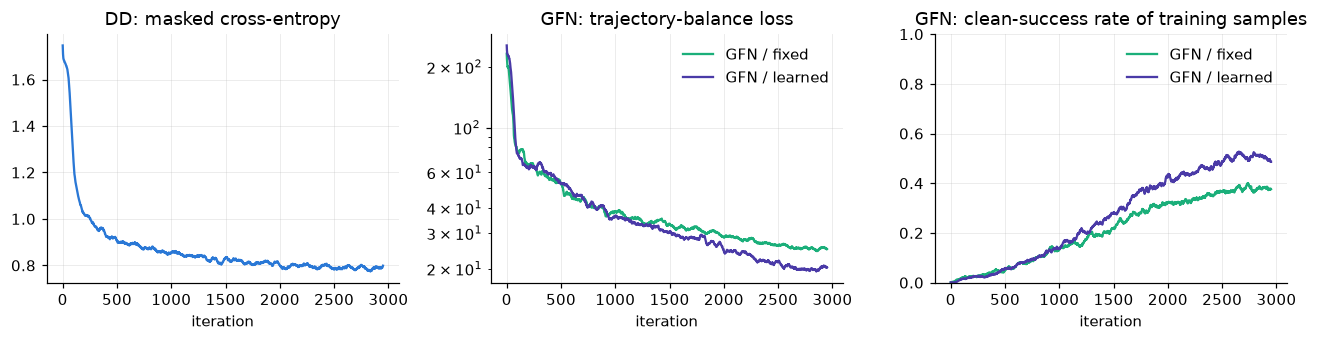

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
sm = lambda v, w=50: np.convolve(v, np.ones(w) / w, mode="valid")
axes[0].plot(sm(dd_hist), color=COL["DD / random"], lw=1.5); axes[0].set_title("DD: masked cross-entropy"); axes[0].set_xlabel("iteration")
for name, h in [("GFN / fixed", gfn_fixed_hist), ("GFN / learned", gfn_learned_hist)]:
    axes[1].plot(sm(h["loss"]), color=COL[name], lw=1.5, label=name)
    axes[2].plot(sm(h["clean"]), color=COL[name], lw=1.5, label=name)
axes[1].set_title("GFN: trajectory-balance loss"); axes[1].set_yscale("log"); axes[1].set_xlabel("iteration"); axes[1].legend()
axes[2].set_title("GFN: clean-success rate of training samples"); axes[2].set_xlabel("iteration"); axes[2].set_ylim(0, 1); axes[2].legend()
plt.tight_layout(); plt.show()

## 8. Fairer baselines: matched data, reward at inference, RL fine-tuning

The comparison above is an ablation of the *objective* on a fixed DAG, but it is not a fair fight: the GFlowNet
gets a simulator with ground-truth geometry, a dense reward, and ~200k fresh scenes, whereas discrete diffusion
sees 6000 fixed demonstrations. Three baselines pull those factors apart:

1. **`DD / 200k demos`**: the same masked-CE decoder trained on a demonstration set as large as the number of
   scenes the GFlowNet queried (isolates data volume).
2. **`DD / best-of-8`**: the 6k-demo DD model, but each returned chunk is the best of 8 samples under the
   simulator reward (reward access at inference only, no training change).
3. **`DD + PG`**: the 6k-demo DD model fine-tuned with a GRPO-style policy gradient on the *same* reward, the
   same simulator, and the same on-policy sample budget as the GFlowNet (8 samples per scene, group-normalised
   log-reward advantages, gradient through the log-probability of the sampled random-order trajectory). This is
   the real competitor: it has everything the GFlowNet has, and differs only in what it optimises, expected
   reward rather than reward-proportional sampling.

In [12]:
DEMOS_200K = make_demos(200_000, np.random.default_rng(SEED + 1))
dd_200k = fresh_model()
dd_200k_hist = train_dd(dd_200k, demos=DEMOS_200K, n_iters=N_ITERS_DD)


def best_of_n(sampler, n=8):
    """Wrap a sampler: draw n chunks per scene and keep the one with the highest simulator reward."""
    def wrapped(sc):
        rep = {k: v.repeat_interleave(n, 0) for k, v in sc.items()}
        x, order = sampler(rep)
        best = log_reward(x, rep).view(-1, n).argmax(1)
        idx = torch.arange(best.shape[0], device=x.device) * n + best
        return x[idx], order[idx]
    return wrapped


def train_pg(model, n_iters=3000, batch=64, group=8, lr=3e-4, log_every=250, seed=3):
    """GRPO-style policy-gradient fine-tuning on whole chunks with the same reward and sampler as the GFlowNet."""
    rng = np.random.default_rng(seed)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, n_iters)
    hist, t0 = {"logR": [], "success": [], "clean": []}, time.time()
    for it in range(1, n_iters + 1):
        sc = to_torch({k: np.repeat(v, group, axis=0) for k, v in sample_scenes(batch // group, rng).items()})
        ctx = model.embed_context(sc["img"], sc["lang"])
        x, states, positions, values, _ = gfn_sample(model, ctx.detach(), learned_order=False, eps=0.0)
        logR = log_reward(x, sc)
        r = logR.view(-1, group)
        adv = ((r - r.mean(1, keepdim=True)) / (r.std(1, keepdim=True) + 1e-6)).view(-1)
        log_pi = policy_terms(model, ctx, states, positions, values, learned_order=False)[2].sum(1)
        loss = -(adv.detach() * log_pi).mean()
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        e = simulate(x, sc)
        hist["logR"].append(logR.mean().item())
        hist["success"].append(e["success"].float().mean().item()); hist["clean"].append(e["clean"].float().mean().item())
        if it % log_every == 0:
            m = lambda k: np.mean(hist[k][-log_every:])
            print(f"[DD + PG] it {it:5d}  logR {m('logR'):6.2f}  on-policy success {m('success'):.2f}  "
                  f"clean {m('clean'):.2f}  ({time.time() - t0:.0f}s)")
    return hist


import copy
dd_pg = copy.deepcopy(dd_model)
dd_pg_hist = train_pg(dd_pg, n_iters=N_ITERS_GFN)

demos: kept 200000/200000 clean successes (100.0%); left-detour fraction = 0.85


[DD] it   250  masked-CE 1.347  (4s)


[DD] it   500  masked-CE 0.965  (8s)


[DD] it   750  masked-CE 0.897  (12s)


[DD] it  1000  masked-CE 0.876  (16s)


...

[DD + PG] it  2000  logR   0.75  on-policy success 0.58  clean 0.52  (101s)


[DD + PG] it  2250  logR   1.01  on-policy success 0.59  clean 0.54  (114s)


[DD + PG] it  2500  logR   1.19  on-policy success 0.60  clean 0.55  (126s)


[DD + PG] it  2750  logR   1.34  on-policy success 0.60  clean 0.57  (139s)


[DD + PG] it  3000  logR   1.51  on-policy success 0.62  clean 0.58  (151s)


## 9. Evaluation on held-out scenes

For each of 200 held-out scenes we draw 16 chunks per decoder and report:

* **success** (final position within the goal radius of the instructed target) and **clean success**
  (success without touching the obstacle), **collision** rate and **wrong-target** rate (closer to the
  distractor than to the instructed target: a language-grounding failure);
* **both modes**: fraction of scenes in which at least 2 of the 16 clean successes go left *and* at least 2 go
  right of the obstacle, and the overall **left fraction** among clean successes (demonstrations: 0.85);
* **distinct**: mean fraction of distinct token chunks among the 16 samples.

In [13]:
EVAL_SCENES, EVAL_SAMPLES = 200, 16
EVAL_SC_NP = sample_scenes(EVAL_SCENES, np.random.default_rng(12345))
EVAL_SC = to_torch({k: np.repeat(v, EVAL_SAMPLES, axis=0) for k, v in EVAL_SC_NP.items()})


@torch.no_grad()
def evaluate(sampler, sc=EVAL_SC, n_samples=EVAL_SAMPLES, chunk=800):
    toks, orders = [], []
    for i in range(0, sc["img"].shape[0], chunk):
        part = {k: v[i:i + chunk] for k, v in sc.items()}
        x, order = sampler(part)
        toks.append(x); orders.append(order)
    tok, order = torch.cat(toks), torch.cat(orders)
    e = simulate(tok, sc)
    n_sc = tok.shape[0] // n_samples
    clean, side = e["clean"].view(n_sc, n_samples), e["side"].view(n_sc, n_samples)
    left = (clean & (side < 0)).sum(1).float()
    right = (clean & (side > 0)).sum(1).float()
    distinct = np.mean([len(set(map(tuple, t.tolist()))) / n_samples for t in tok.view(n_sc, n_samples, L)])
    metrics = dict(
        success=e["success"].float().mean().item(), clean=e["clean"].float().mean().item(),
        collision=(e["coll"] > 0).float().mean().item(), wrong_target=(e["d_other"] < e["d_goal"]).float().mean().item(),
        both_modes=((left >= 2) & (right >= 2)).float().mean().item(),
        left_frac=(left.sum() / (left + right).sum().clamp(min=1)).item(),
        distinct=float(distinct), mean_logR=log_reward(tok, sc).mean().item(),
    )
    return metrics, dict(tok=tok, order=order, **e)


def dd_sampler(model, order="random"):
    return lambda sc: dd_sample(model, model.embed_context(sc["img"], sc["lang"]), order=order)


def gfn_sampler(model, learned_order):
    return lambda sc: (lambda r: (r[0], r[4]))(gfn_sample(model, model.embed_context(sc["img"], sc["lang"]), learned_order=learned_order))


SAMPLERS = {
    "DD / random":      dd_sampler(dd_model, "random"),
    "DD / confidence":  dd_sampler(dd_model, "confidence"),
    "DD / 200k demos":  dd_sampler(dd_200k, "random"),
    "DD / best-of-8":   best_of_n(dd_sampler(dd_model, "random"), n=8),
    "DD + PG":          dd_sampler(dd_pg, "random"),
    "GFN / fixed":      gfn_sampler(gfn_fixed, learned_order=False),
    "GFN / learned":    gfn_sampler(gfn_learned, learned_order=True),
}
RESULTS, RAW = {}, {}
for name, sampler in SAMPLERS.items():
    RESULTS[name], RAW[name] = evaluate(sampler)

cols = ["success", "clean", "collision", "wrong_target", "both_modes", "left_frac", "distinct", "mean_logR"]
print(f"{'decoder':18s}" + "".join(f"{c:>13s}" for c in cols))
for name, m in RESULTS.items():
    print(f"{name:18s}" + "".join(f"{m[c]:13.3f}" for c in cols))
print("\n(DD / best-of-8 and DD + PG use the simulator reward; DD / 200k demos matches the GFlowNet's scene budget)")

decoder                 success        clean    collision wrong_target   both_modes    left_frac     distinct    mean_logR
DD / random               0.339        0.224        0.385        0.062        0.000        0.999        0.999       -5.556
DD / confidence           0.335        0.235        0.341        0.054        0.000        0.999        0.999       -5.057
DD / 200k demos           0.337        0.221        0.399        0.056        0.000        0.999        0.998       -5.642
DD / best-of-8            0.835        0.820        0.021        0.002        0.005        0.997        0.997        4.395
DD + PG                   0.593        0.570        0.056        0.010        0.000        1.000        0.348        1.446
GFN / fixed               0.469        0.389        0.172        0.036        0.130        0.907        1.000       -1.356
GFN / learned             0.613        0.516        0.164        0.017        0.035        0.960        1.000        0.428

(DD / best-of-8

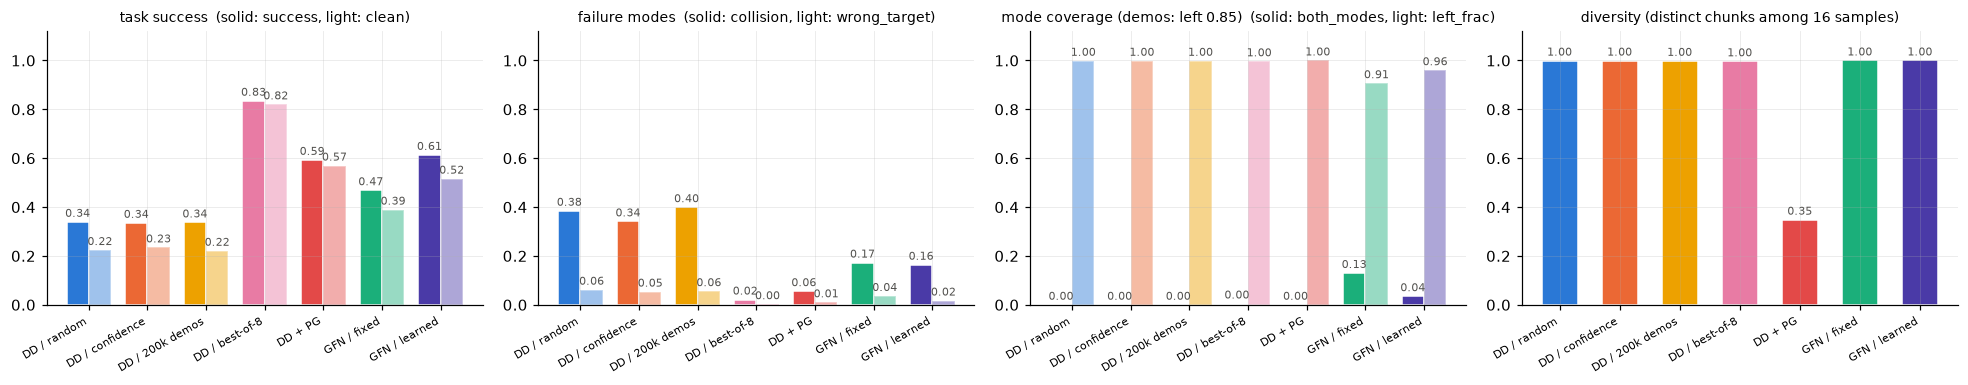

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
names = list(RESULTS)
for ax, keys, title in [(axes[0], ["success", "clean"], "task success"),
                        (axes[1], ["collision", "wrong_target"], "failure modes"),
                        (axes[2], ["both_modes", "left_frac"], "mode coverage (demos: left 0.85)")]:
    w = 0.38
    for j, k in enumerate(keys):
        vals = [RESULTS[n][k] for n in names]
        bars = ax.bar(np.arange(len(names)) + (j - 0.5) * w, vals, w, color=[COL[n] for n in names],
                      alpha=1.0 if j == 0 else 0.45, edgecolor="white", linewidth=1)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=7, color="#52514e")
    ax.set_xticks(np.arange(len(names))); ax.set_xticklabels(names, rotation=30, ha="right", fontsize=7)
    ax.set_ylim(0, 1.12); ax.set_title(title + f"  (solid: {keys[0]}, light: {keys[1]})", fontsize=9)
ax = axes[3]
vals = [RESULTS[n]["distinct"] for n in names]
bars = ax.bar(np.arange(len(names)), vals, 0.6, color=[COL[n] for n in names], edgecolor="white", linewidth=1)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=7, color="#52514e")
ax.set_xticks(np.arange(len(names))); ax.set_xticklabels(names, rotation=30, ha="right", fontsize=7)
ax.set_ylim(0, 1.12); ax.set_title("diversity (distinct chunks among 16 samples)", fontsize=9)
plt.tight_layout(); plt.show()

## 10. What the decoders sample

Each panel overlays the 16 sampled chunks for one held-out scene: coloured paths are clean successes, grey
paths fail (collision, wrong target, or short of the goal).

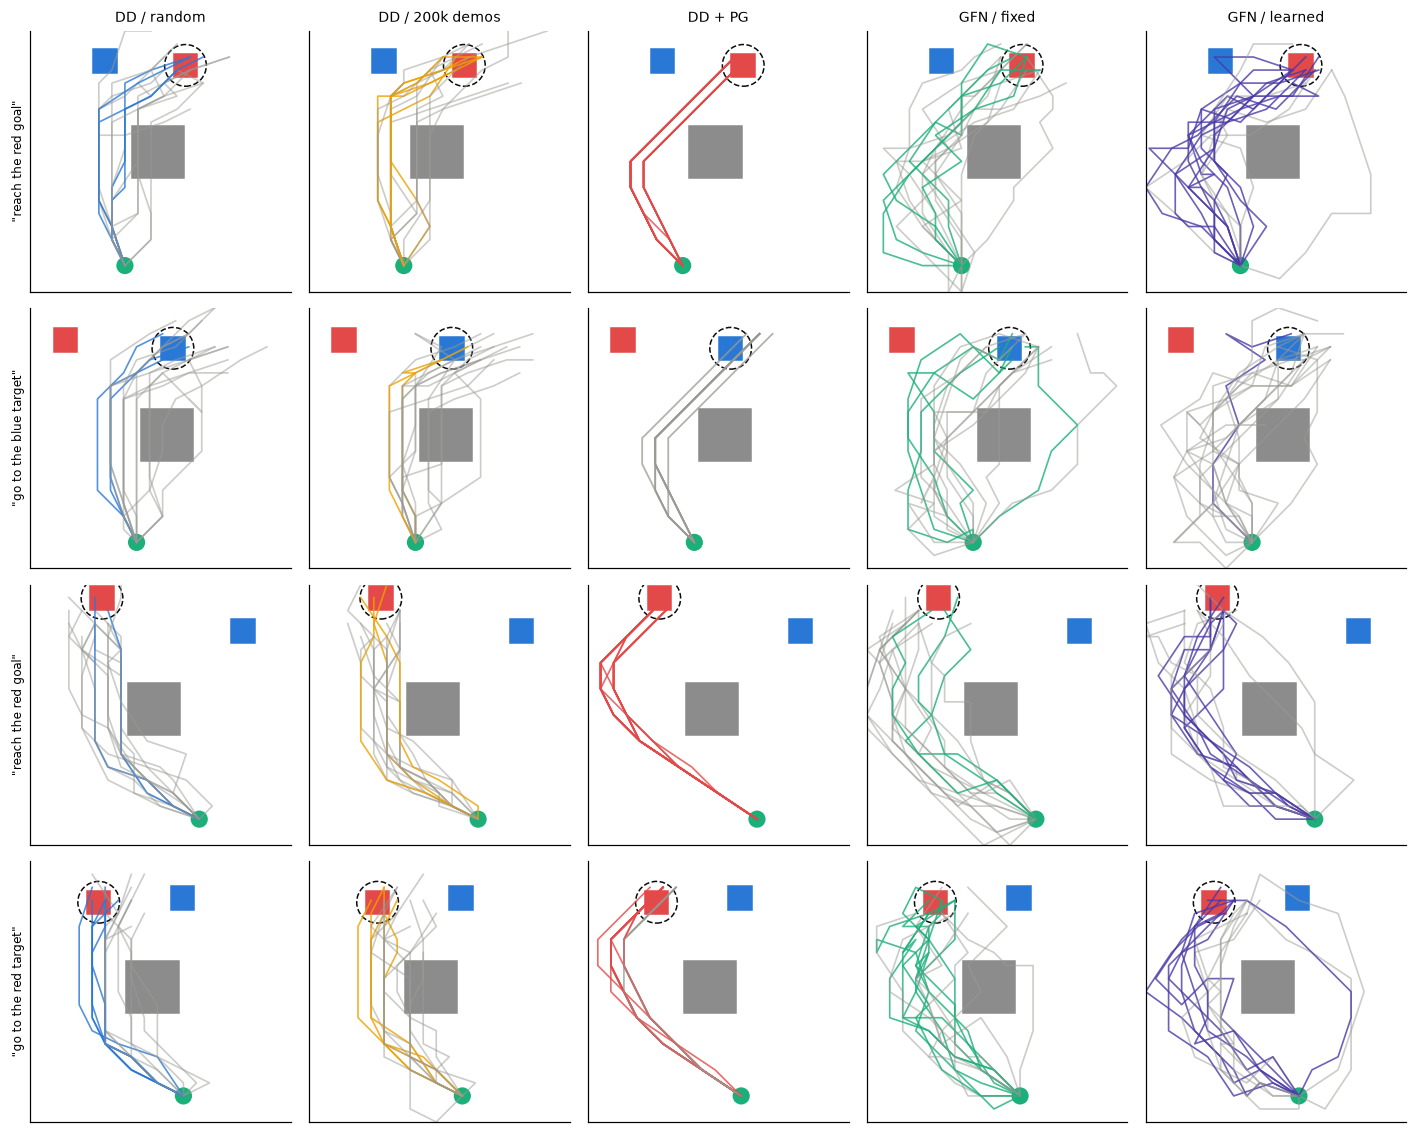

In [15]:
show = [0, 1, 2, 3]
show_names = ["DD / random", "DD / 200k demos", "DD + PG", "GFN / fixed", "GFN / learned"]
fig, axes = plt.subplots(len(show), len(show_names), figsize=(2.6 * len(show_names), 2.6 * len(show)))
for r, s in enumerate(show):
    for c, name in enumerate(show_names):
        ax = axes[r, c]
        draw_scene(ax, EVAL_SC_NP, s, title=name if r == 0 else None)
        sl = slice(s * EVAL_SAMPLES, (s + 1) * EVAL_SAMPLES)
        pos, clean = RAW[name]["pos"][sl].cpu().numpy(), RAW[name]["clean"][sl].cpu().numpy()
        for p, ok in zip(pos, clean):
            ax.plot(p[:, 0], p[:, 1], "-", lw=1.1, alpha=0.8 if ok else 0.5, color=COL[name] if ok else COL["fail"])
        if c == 0:
            ax.set_ylabel(f'"{decode_instruction(EVAL_SC_NP["lang"][s].tolist())}"', fontsize=8)
plt.tight_layout(); plt.show()

## 11. Generation order: heuristic vs learned

Mean reveal step of each action token (row = chunk step `t`, column = `dx`/`dy`), averaged over all
evaluation samples, and the entropy of the position choice at each decoding step.

Random order is flat by construction and the confidence heuristic clearly is not (it resolves `dy`, "go up",
before `dx`, and mid-chunk `dx` tokens before the ends). The learned order, however, comes out **uniform**:
its entropy sits on the `log(#masked)` curve. This is not a gradient bug (the select head receives gradients of
the same size as the value head); it is a property of the objective. With a learned `P_B`, *every* reveal order
is consistent with trajectory balance, so the symmetric initialisation is a fixed point and the gradients on
the order policy are zero-mean noise. In other words: the DAG with free order is the right formulation, a learned
backward policy is necessary for the order to be free at all, but TB alone supplies no criterion for *which*
order to prefer. `train_gfn(..., order_coef=0.1)` adds a REINFORCE-style term that favours orders with small TB
residual (an amortised cousin of the entropy heuristic); at this scale it is too noisy to break the symmetry
either. A criterion in which the order genuinely matters, e.g. block-parallel reveals where tokens revealed
together are sampled independently, is the natural next experiment (see section 13).

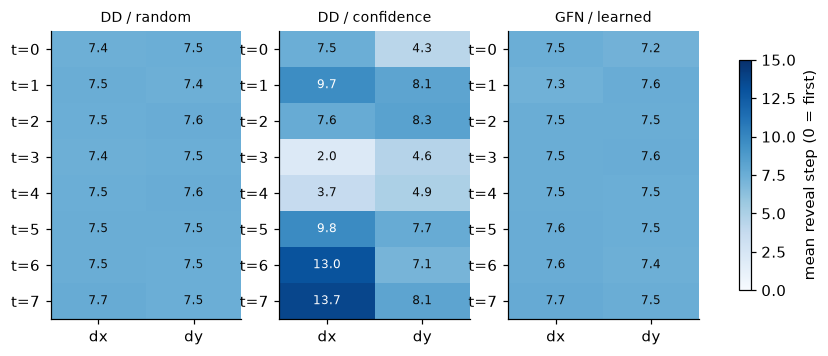

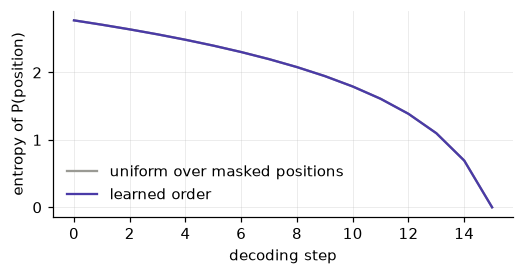

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.4))
for ax, name in zip(axes, ["DD / random", "DD / confidence", "GFN / learned"]):
    mean_step = RAW[name]["order"].float().mean(0).view(cfg.H, cfg.D).cpu().numpy()
    im = ax.imshow(mean_step, cmap="Blues", vmin=0, vmax=L - 1, aspect="auto")
    for t in range(cfg.H):
        for d in range(cfg.D):
            v = mean_step[t, d]
            ax.text(d, t, f"{v:.1f}", ha="center", va="center", fontsize=8, color="white" if v > 0.6 * L else "#0b0b0b")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["dx", "dy"]); ax.set_yticks(range(cfg.H)); ax.set_yticklabels([f"t={t}" for t in range(cfg.H)])
    ax.set_title(name, fontsize=9); ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8, label="mean reveal step (0 = first)")
plt.show()

# Entropy of the position choice at each step for the learned order, on a few evaluation scenes.
with torch.no_grad():
    part = {k: v[:256] for k, v in EVAL_SC.items()}
    ctx = gfn_learned.embed_context(part["img"], part["lang"])
    x = torch.full((256, L), MASK, dtype=torch.long, device=DEVICE)
    ents = []
    for step in range(L):
        _, sl, _, _ = gfn_learned(ctx, x)
        masked = x == MASK
        p = F.softmax(sl.masked_fill(~masked, -1e9), -1)
        ents.append((-(p * torch.log(p + 1e-9)).sum(-1)).mean().item())
        pos = torch.multinomial(p, 1).squeeze(1)
        vl, _, _, _ = gfn_learned(ctx, x)
        x[torch.arange(256, device=DEVICE), pos] = torch.multinomial(F.softmax(vl[torch.arange(256, device=DEVICE), pos], -1), 1).squeeze(1)
plt.figure(figsize=(5, 2.6))
plt.plot(range(L), [math.log(L - s) for s in range(L)], color=COL["fail"], lw=1.5, label="uniform over masked positions")
plt.plot(range(L), ents, color=COL["GFN / learned"], lw=1.5, label="learned order")
plt.xlabel("decoding step"); plt.ylabel("entropy of P(position)"); plt.legend(); plt.tight_layout(); plt.show()

## 12. Parallel decoding

Discrete-diffusion VLAs reveal several tokens per step for latency. Revealing tokens in parallel samples them
*independently* given the current state, which can mix action modes inside one chunk. The same parallel
schedule can be applied to any of the trained value heads; this cell shows how success degrades with fewer
steps for the DD model and the fixed-order GFN model (whose value head is the same object, trained differently).

What to look for: the imitation model is nearly deterministic given the scene, so its token marginals are
close to independent and parallel decoding costs it little; the GFlowNet represents a much broader
reward-proportional distribution whose tokens are strongly coupled (left *or* right detour), so it loses most of
its advantage when tokens are revealed independently. A GFlowNet meant for parallel decoding should be trained on
the block-reveal DAG it will be sampled with.

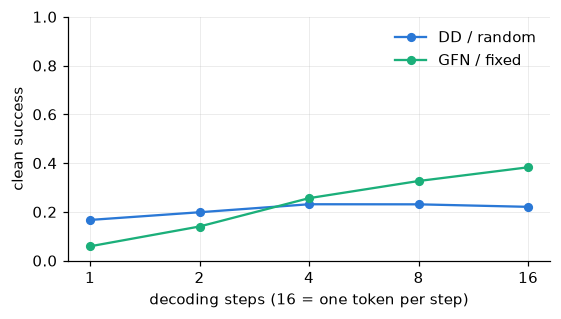

In [17]:
steps_grid = [16, 8, 4, 2, 1]
rows = []
for name, model in [("DD / random", dd_model), ("GFN / fixed", gfn_fixed)]:
    for n_steps in steps_grid:
        m, _ = evaluate(lambda sc, model=model, n_steps=n_steps:
                        dd_sample(model, model.embed_context(sc["img"], sc["lang"]), order="random", n_steps=n_steps))
        rows.append((name, n_steps, m["clean"], m["both_modes"]))
plt.figure(figsize=(5.2, 3))
for name in ["DD / random", "GFN / fixed"]:
    r = [x for x in rows if x[0] == name]
    plt.plot([x[1] for x in r], [x[2] for x in r], "-o", ms=5, lw=1.5, color=COL[name], label=name)
plt.xscale("log", base=2); plt.xticks(steps_grid, steps_grid); plt.xlabel("decoding steps (16 = one token per step)")
plt.ylabel("clean success"); plt.ylim(0, 1); plt.legend(); plt.tight_layout(); plt.show()

## 13. Notes from building this, and where to go from here

**What to expect from the numbers.** Across the runs used to build this notebook (3000 GFlowNet iterations),
the GFlowNet decoders reached ~45-60% success with ~17-30% collisions, versus ~35-40% success and ~35%
collisions for the discrete-diffusion baseline trained on the 85/15 demonstrations, and ~2-4% wrong-target
errors for everyone (grounding comes from the shared backbone). Mode coverage is the seed-sensitive part:
the DD baseline essentially never executes a clean right-hand detour, while the GFlowNet recovered both
detours in anywhere between ~10% and ~35% of held-out scenes depending on the run, with the left/right split
drifting from the demo bias towards 50/50 as training continues. The learned order did not differ from the
random order (see section 11). Longer GFlowNet training (the TB loss is still far from zero at 3000
iterations) keeps improving success and mode balance.

**What the fairer baselines say (section 8).**
* *Data volume is not what holds imitation back.* 200k demonstrations give the same ~33% success as 6k: the
  masked-CE decoder is limited by how precisely it can reproduce a fragile token pattern from pixels, not by data.
* *Reward access at inference is the strongest single ingredient.* Best-of-8 under the simulator reward lifts the
  6k-demo DD model to ~84% success with ~2% collisions, far above every trained decoder here, but it still never
  leaves the demonstrated mode and it needs eight simulator rollouts per action chunk.
* *Policy-gradient fine-tuning beats the GFlowNet on success, and collapses.* With the same reward, simulator and
  on-policy budget, GRPO-style fine-tuning reaches ~58% clean success and ~7% collisions, better than TB's
  ~40-53% and ~17-19%. The price is diversity: only ~40% of its 16 samples per scene are distinct chunks (the
  GFlowNets: 100%), and it executes exactly one detour. This is the trade-off the proposal predicts, reward
  maximisation versus reward-proportional sampling, and it is what the GFlowNet buys at this scale: not higher
  success, but a decoder whose samples are a distribution rather than a point. Whether that matters is a question
  about the downstream use (human selection among proposals, exploration for further learning, robustness to a
  mis-specified reward), not something this toy can settle.

**Things that mattered.**
* *Backbone grounding.* Without the grounding pre-training, neither decoder learns to pick the instructed
  target from the image in a few thousand steps (wrong-target rate near chance). Real VLAs get this from the VLM.
* *Reward sharpness.* With a flat reward (e.g. `BONUS_SUCCESS = 2`, `BETA_COLL = 10`) the exact
  reward-proportional distribution itself has only ~50% success, so a perfectly trained GFlowNet would look
  mediocre. The reward defines the target; make it as peaked as the task demands.
* *Replay.* Pure on-policy TB is slow here. A single prioritised FIFO buffer that is seeded with the demos and then
  evicts them collapses onto the first mode found (success goes *up*, mode coverage goes to zero), which is why
  `train_gfn` keeps the demonstration buffer separate when `use_demos=True`.
* *Warm-starting from the DD model* (copy `dd_model`'s weights and run `train_gfn`) does **not** give a quick win
  here: TB first spreads the peaked imitation policy over the whole high-reward set, so success drops before it
  recovers. Initialising log Z sensibly (or the VarGrad / in-batch log Z estimate) softens but does not remove this.

**Extensions that map onto the proposal.**
* **Compositional rewards.** `log_reward` is the place to add a VLM-judge score, joint limits, or any MPC-style
  cost term; nothing else changes. Multiplying in an imitation prior (e.g. the DD model's likelihood) gives
  "demonstrations + reward" training.
* **Outcome-conditioned pre-training (OC-GFN).** Condition the policy on a desired final position instead of a
  reward, train reward-free on random outcomes, and recover the reward-driven policy by amortised fine-tuning.
* **Parallel decoding and learned order, together.** Redefine the DAG so that an edge reveals a *block* of
  tokens sampled independently; TB applies unchanged with a backward policy over blocks. In that DAG the order
  is no longer a free choice: grouping conditionally dependent tokens (the two sides of a detour) into one block
  breaks balance, so the order policy gets a real training signal, which is exactly what section 11 found to be
  missing in the one-token-per-step DAG. Sub-trajectory balance (a flow head per state) is a drop-in alternative
  to TB on either DAG.
* **Scaling up.** Replace `ToyVLA` by a real VLM backbone with an action-token vocabulary (OpenVLA-style
  binning or a VQ tokenizer), `simulate` by LIBERO / SimplerEnv rollouts (or a learned success verifier), and
  compare against the autoregressive and continuous-diffusion heads on the same backbone.